# Clase del 14 de septiembre

## Regresión lineal

In [ ]:
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "dataset.xlsx"

data = pd.read_excel(DATA_PATH)
df = pd.DataFrame(data)

df.head(7)

,VehicleManufacturerName,TestVehDisplacement,RatedHorsepower,TestedTransmissionType,NoOfGears,DriveSystemDescription,EquivalentTestWeight,AxleRatio,TestFuelTypeDescription,TestCategory,AftertreatmentDevice,CO2Emissions,MPG
0,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,HWY,Three-way catalyst,287.0,30.7
1,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Cold CO Premium (Tier 2),FTP,Three-way catalyst,467.0,18.8
2,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,FTP,Three-way catalyst,389.0,22.7
3,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,SC03,Three-way catalyst,475.0,18.6
4,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,US06,Three-way catalyst,411.0,21.4


In [ ]:
# El profesor hizo el análisis previo, para encontrar aquellas variables con datos faltantes
# Las filas que se eliminan a continuación son el resultado de aquel ejercicio
df1 = df.dropna(subset=["CO2Emissions", "MPG", "AftertreatmentDevice"]).copy()
df1.head(7)

,VehicleManufacturerName,TestVehDisplacement,RatedHorsepower,TestedTransmissionType,NoOfGears,DriveSystemDescription,EquivalentTestWeight,AxleRatio,TestFuelTypeDescription,TestCategory,AftertreatmentDevice,CO2Emissions,MPG
0,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,HWY,Three-way catalyst,287.0,30.7
1,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Cold CO Premium (Tier 2),FTP,Three-way catalyst,467.0,18.8
2,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,FTP,Three-way catalyst,389.0,22.7
3,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,SC03,Three-way catalyst,475.0,18.6
4,Audi,3.179,270,Automatic,6,"2-Wheel Drive, Front",4500,4.22,Tier 2 Cert Gasoline,US06,Three-way catalyst,411.0,21.4
7,Audi,3.000,225,Automatic,6,All Wheel Drive,6000,3.90,Federal Cert Diesel 7-15 PPM Sulfur,US06,Diesel Particulate Filter,438.0,23.2
8,Audi,3.000,225,Automatic,6,All Wheel Drive,6000,3.90,Federal Cert Diesel 7-15 PPM Sulfur,US06,Oxidation catalyst,438.0,23.2


In [8]:
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
import pandas as pd

df_encoded = df1.copy()

categorical_columns = ["VehicleManufacturerName","TestedTransmissionType","DriveSystemDescription","TestCategory","TestFuelTypeDescription","AftertreatmentDevice"]
label_encoders = {}
mapping_tables = {}

for col in categorical_columns:
    le = LabelEncoder()
    # Replace original values with encoded values
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str)) 
    label_encoders[col] = le
    # Save category-to-number mapping
    mapping_tables[col] = pd.DataFrame({
            "Category": le.classes_,
            "Encoded Value": le.transform(le.classes_)
        })

# Display mappings
for col, mapping in mapping_tables.items():
    print(f"\nMapping for {col}:")
    display(mapping)



Mapping for VehicleManufacturerName:


,Category,Encoded Value
0,Audi,0
1,BMW,1
2,FCA US LLC,2
3,FOMOCO,3
4,GM,4
5,Honda,5
6,Hyundai,6
7,Kia,7
8,Land Rover,8
9,MAZDA,9



Mapping for TestedTransmissionType:


,Category,Encoded Value
0,Automatic,0
1,Continuously Variable,1
2,Manual,2
3,Other,3
4,Semi-Automatic,4



Mapping for DriveSystemDescription:


...

,Category,Encoded Value
0,FTP,0
1,HWY,1
2,SC03,2
3,US06,3



Mapping for TestFuelTypeDescription:


,Category,Encoded Value
0,CARB Phase II Gasoline,0
1,Cold CO Premium (Tier 2),1
2,Cold CO Regular (CERT),2
3,E85 (85% Ethanol 15% EPA Unleaded Gasoline),3
4,Federal Cert Diesel 7-15 PPM Sulfur,4
5,Tier 2 Cert Gasoline,5



Mapping for AftertreatmentDevice:


,Category,Encoded Value
0,Diesel Particulate Filter,0
1,HC-Adsorber,1
2,Oxidation catalyst,2
3,Selective Catalytic Reduction,3
4,Three-way catalyst,4


In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

feature_cols = [c for c in df_encoded.columns if c not in ["CO2Emissions", "MPG"]]
data_annova = df_encoded[feature_cols + ["CO2Emissions"]].dropna()

X = data_annova[feature_cols]
y = data_annova["CO2Emissions"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit() # Linear regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           CO2Emissions   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     86.81
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.05e-124
Time:                        17:19:46   Log-Likelihood:                -4227.7
No. Observations:                 744   AIC:                             8479.
Df Residuals:                     732   BIC:                             8535.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Multiple Perceptor Network (MLP)

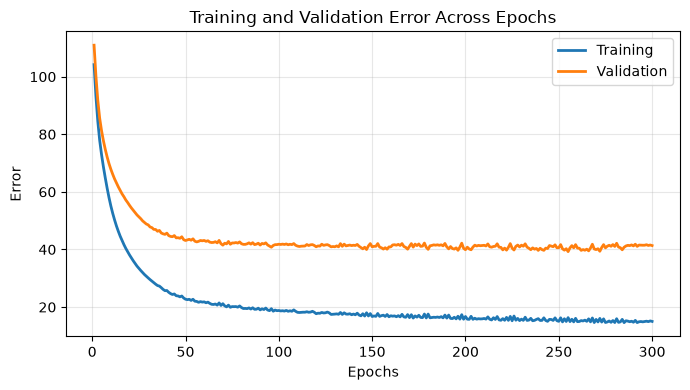

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

feature_cols = [c for c in df_encoded.columns if c not in ["CO2Emissions", "MPG"]]
data_model = df_encoded[feature_cols + ["CO2Emissions"]].dropna()

X = data_model[feature_cols].to_numpy()
y = data_model["CO2Emissions"].to_numpy().reshape(-1, 1) # Se ajusta la 'y' para que funcione mejor la función de activación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Se usa StandardScaler() para el óptimo desarrollo de MLP
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

# Aquí se hace la magia: MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32), # 64 es el tamaño de la primera capa y 32 en la segunda
    activation="relu", # Se usa relu function como función de activación
    solver="adam", # Gradient descent method
    learning_rate_init=0.001, # Diferencias de epoch que se hacen: a mayor tamaño, mayor brusquedad de los cambios
    max_iter=1, # Cantidad de iteraciones
    warm_start=True, 
    random_state=42, 
    shuffle=True)
epochs = 300 # Cada epoch involucra un ciclo de feed forward y backward propagation

train_error = []
validation_error = []

for epoch in range(epochs):
    mlp.fit(X_train, y_train_scaled)
    y_train_pred_scaled = mlp.predict(X_train)
    y_test_pred_scaled = mlp.predict(X_test)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()
    train_rmse = np.sqrt(mean_squared_error(y_train.ravel(), y_train_pred))
    validation_rmse = np.sqrt(mean_squared_error(y_test.ravel(), y_test_pred))
    train_error.append(train_rmse)
    validation_error.append(validation_rmse)

y_pred_scaled = mlp.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = y_test.ravel()

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_error, linewidth=2, label="Training")
plt.plot(range(1, epochs + 1), validation_error, linewidth=2, label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Training and Validation Error Across Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()